In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
from tabulate import tabulate

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import \
    StepCalculatorZhangLambda, StepCalculatorEtaSoftmaxArmihoNorm2, StepCalculatorEtaSoftmaxArmihoNorm1\
    , StepCalculatorEtaSoftmaxArmihoNorm2Base, StepCalculatorEtaSoftmaxArmihoNorm1Base\
        , StepCalculatorZhangSimplified, reduce_to_active
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
#from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_eminst_epochsd.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 128 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available


##### UTILS

In [6]:
def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (cross-entropy)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)

    fig2, ax2 = plt.subplots(1, 1, figsize=(20, 6))
    ax2.set_title('Train-step eta')
    ax2.plot(HISTORY_PARAMS['train_eta']) #, label='Train-step eta'
    ax2.grid()
    #ax2.legend(fontsize=20)    
    
    plt.show()

HISTORY_PARAMS = collections.defaultdict(list)

#### L_b, L_w

In [ ]:
#for lb in , lw = 1e-2, 7.5
lbs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
lws = [0.1, 0.5, 1, 2.5, 5, 7.5, 10, 20]
results = []
head = ["lb", "lw", "loss", "accuracy"]

for lb, lw in [(a,b) for a in lbs for b in lws]:
    meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                    , batch_size = BATCH_SIZE, lb = lb, lw = lw)
    
    stepCalcZh = StepCalculatorZhangLambda(meta)
    stepCalcSoftmax = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
    testNet = MNISTReLU(meta)
    testNet.set_log_level("info")
    testNet.set_slopes(slope_plus, slope_minus)
    testNet.init_weights(cb, cw)
    testNet.to(DEVICE)    
    # training loop
    for train_batch in train_dataloader:
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.90:
            logging.info("##Step with Zh-optim")
            eta, logits_latest = stepCalcZh.step(testNet, logits_detached, labels, xx)
        else:
            logging.info("##Step with norm2 optim")
            eta, logits_latest = stepCalcSoftmax.step(testNet, logits_detached, labels, xx)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    #results
    results.append([lb, lw, test_loss_meter.avg, test_accuracy_meter.avg])
    display.clear_output()
    print(tabulate(results, headers=head, tablefmt="grid"))


#### Eta_max

In [ ]:
#for lb in , lw = 1e-2, 7.5
eta_ratio_limits = [1.0, 1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.5,4.0,5.0,0.0]
results = []
head = ["eta_max", "loss", "accuracy"]

eta = 0.0
for eta_ratio_limit in eta_ratio_limits:
    meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                    , batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0) #0.005, 5.0
    
    stepCalcZh = StepCalculatorZhangLambda(meta)
    stepCalcSoftmax = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
    testNet = MNISTReLU(meta)
    testNet.set_log_level("info")
    testNet.set_slopes(slope_plus, slope_minus)
    testNet.init_weights(cb, cw)
    testNet.to(DEVICE)
    # training loop
    for train_batch in train_dataloader:
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.90:
            logging.info("##Step with Zh-optim")
            eta, logits_latest = stepCalcZh.step(testNet, logits_detached, labels, xx)
        else:
            logging.info("##Step with norm2 optim")
            eta, logits_latest = stepCalcSoftmax.step(testNet, logits_detached, labels, xx, eta*eta_ratio_limit)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    #results
    results.append([eta_ratio_limit, test_loss_meter.avg, test_accuracy_meter.avg])
    display.clear_output()
    print(tabulate(results, headers=head, tablefmt="grid"))


+-----------+----------+------------+
|   eta_max |     loss |   accuracy |
+===========+==========+============+
|      1    | 0.748279 |   0.786618 |
+-----------+----------+------------+
|      1.25 | 0.461366 |   0.858273 |
+-----------+----------+------------+
|      1.5  | 0.451463 |   0.864599 |
+-----------+----------+------------+
|      1.75 | 0.455727 |   0.858896 |
+-----------+----------+------------+
|      2    | 0.489486 |   0.851802 |
+-----------+----------+------------+
|      2.25 | 0.455256 |   0.860861 |
+-----------+----------+------------+
|      2.5  | 0.446125 |   0.860765 |
+-----------+----------+------------+
|      2.75 | 0.467262 |   0.853432 |
+-----------+----------+------------+
|      3    | 0.452638 |   0.857266 |
+-----------+----------+------------+
|      3.5  | 0.443282 |   0.863497 |
+-----------+----------+------------+
|      4    | 0.4381   |   0.865174 |
+-----------+----------+------------+
|      5    | 0.469761 |   0.85439  |
+-----------

#### Debug for zero_grad

In [ ]:
def printData(direct, delta):
    print("Direct: min={}, max={}, abs aggr={}".format(np.min(direct), np.max(direct), np.sum(np.abs(direct))))
    print("Deltas: min={}, max={}, abs aggr={}".format(np.min(delta), np.max(delta), np.sum(np.abs(delta)))) 

testNetOpt = MNISTReLU(meta)
testNetOpt.set_log_level("info")
testNetOpt.set_slopes(slope_plus, slope_minus)
testNetOpt.init_weights(cb, cw)
testNetOpt.to(DEVICE)

testNetOpt.save_txt("tmp")
testNetMan = MNISTReLU(meta)
testNetMan.set_slopes(slope_plus, slope_minus)
testNetMan.init_weights_txt('tmp')
testNetMan.to(DEVICE)
#testNetMan.forward_(xx)

STEPS = 5

stepCalcZh = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
loss_fn = nn.CrossEntropyLoss(reduction='sum')
#loss_fnSoftmax = torch.linalg.matrix_norm(1-nn.LogSoftmax(dim=1), ord='fro')
optimizer = optim.SGD(testNetOpt.parameters(), lr=1e-2)

output0_fc_w = testNetOpt.output_fc.weight.detach().numpy()
output0_fc_b = testNetOpt.output_fc.bias.detach().numpy()
hidden0_fc_w = testNetOpt.hidden_fc.weight.detach().numpy()
hidden0_fc_b = testNetOpt.hidden_fc.bias.detach().numpy()
input0_fc_w = testNetOpt.input_fc.weight.detach().numpy()
input0_fc_b = testNetOpt.input_fc.bias.detach().numpy()

for step in range(STEPS):
    print("STEP NUMBER {}".format(step))
    images, labels_raw = next(iter(train_dataloader))
    labels = labels_raw - 1
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)

    logging.info("##Step with Zhang-torch optim")
    optimizer.zero_grad()
    logits1 = testNetOpt.forward_(xx)
    logits_detached = logits1.detach().numpy()
    loss = loss_fn(logits1, labels)
    loss.backward()
    output1OptDelta_fc_b = testNetOpt.output_fc.bias.grad.detach().numpy()
    print("Grad bias optim:\n{}".format(output1OptDelta_fc_b))
    etaOpt = stepCalcZh.calc_eta(testNetOpt, loss.item())

    optimizer.param_groups[0]['lr'] = etaOpt # set learning rate
    optimizer.step()
    output1Opt_fc_w = testNetOpt.output_fc.weight.detach().numpy()
    output1Opt_fc_b = testNetOpt.output_fc.bias.detach().numpy()
    hidden1Opt_fc_w = testNetOpt.hidden_fc.weight.detach().numpy()
    hidden1Opt_fc_b = testNetOpt.hidden_fc.bias.detach().numpy()
    input1Opt_fc_w = testNetOpt.input_fc.weight.detach().numpy()
    input1Opt_fc_b = testNetOpt.input_fc.bias.detach().numpy()

    logging.info("##Step with Zhang-direct optim")
    testNetMan.zero_grad()
    logits2 = testNetMan.forward_(xx)
    loss = stepCalcZh.criterion(logits2, labels)
    loss.backward()
    etaMan = stepCalcZh.calc_eta(testNetOpt, loss.item())
    stepCalcZh.calculate_deltasZhEta(testNetMan, etaMan)
    output1ManDelta_fc_b = stepCalcZh.delta_bias_02.numpy()/-etaMan
    print("Grad bias direct:\n{}".format(output1ManDelta_fc_b))
    stepCalcZh.do_step0(testNetMan, 1.0)
    #eta, logits_latest = stepCalcZh.step(testNetMan, logits_detached, labels, xx)
    output1Man_fc_w = testNetMan.output_fc.weight.detach().numpy() #.grad
    output1Man_fc_b = testNetMan.output_fc.bias.detach().numpy()
    hidden1Man_fc_w = testNetMan.hidden_fc.weight.detach().numpy()
    hidden1Man_fc_b = testNetMan.hidden_fc.bias.detach().numpy()
    input1Man_fc_w = testNetMan.input_fc.weight.detach().numpy()
    input1Man_fc_b = testNetMan.input_fc.bias.detach().numpy()


    print("Etas optim={}, man={}:".format(etaOpt, etaMan))
    print("Output weights:")
    printData(output1Man_fc_w, output1Opt_fc_w-output1Man_fc_w)
    print("Output biases:")
    printData(output1Man_fc_b, output1Opt_fc_b-output1Man_fc_b)

    print("Hidden weights:")
    printData(hidden1Man_fc_w, hidden1Opt_fc_w-hidden1Man_fc_w)
    print("Hidden biases:")
    printData(hidden1Man_fc_b, hidden1Opt_fc_b-hidden1Man_fc_b)

    print("Input weights:")
    printData(input1Man_fc_w, input1Opt_fc_w-input1Man_fc_w)
    print("Input biases:")
    printData(input1Man_fc_b, input1Opt_fc_b-input1Man_fc_b)

In [10]:
HISTORY_NORM1L = collections.defaultdict(list)
HISTORY_NORM2L = collections.defaultdict(list)
HISTORY_NORM1S = collections.defaultdict(list)
HISTORY_NORM2S = collections.defaultdict(list)
HISTORY_ZHS = collections.defaultdict(list)
HISTORY_ZHL = collections.defaultdict(list)
HISTORY_OPTADA = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

#### Compare optimisers

In [11]:
def print_comparison(low, high):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_NORM1L['test_loss'][low:high], color='g', ls='dotted',alpha=.5, label='Test norm1-lambda')
    axes[0].plot(HISTORY_NORM2L['test_loss'][low:high], color='b', ls='dotted',alpha=.5, label='Test norm2-lambda')
    axes[0].plot(HISTORY_NORM1S['test_loss'][low:high], color='g', alpha=.5, label='Test norm1-simple')
    axes[0].plot(HISTORY_NORM2S['test_loss'][low:high], color='b', alpha=.5, label='Test norm2-simple')    
    axes[0].plot(HISTORY_ZHS['test_loss'][low:high], color='r', alpha=.5, label='Test Zhang-simple')
    axes[0].plot(HISTORY_ZHL['test_loss'][low:high], color='r', ls='dotted', alpha=.5, label='Test Zhang-lambda')
    axes[0].plot(HISTORY_OPTADA['test_loss'][low:high], color='orange', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'][low:high], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_NORM1L['test_accuracy'][low:high], color='g', ls='dotted', alpha=.5, label='Test norm1-lambda')
    axes[1].plot(HISTORY_NORM2L['test_accuracy'][low:high], color='b', ls='dotted', alpha=.5, label='Test norm2-lambda')
    axes[1].plot(HISTORY_NORM1S['test_accuracy'][low:high], color='g', alpha=.5, label='Test norm1-simple')
    axes[1].plot(HISTORY_NORM2S['test_accuracy'][low:high], color='b', alpha=.5, label='Test norm2-simple')
    axes[1].plot(HISTORY_ZHS['test_accuracy'][low:high], color='r', alpha=.5, label='Test Zhang-simple')
    axes[1].plot(HISTORY_ZHL['test_accuracy'][low:high], color='r', ls='dotted', alpha=.5, label='Test Zhang-lambda')
    axes[1].plot(HISTORY_OPTADA['test_accuracy'][low:high], color='orange', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'][low:high], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

In [ ]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = labels_raw - 1
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 20

#results = []
#head = ["type", "loss", "accuracy"]

meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

stepCalcZhL = StepCalculatorZhangLambda(meta)
stepCalcZhS = StepCalculatorZhangSimplified(meta)
stepCalcSoftmaxL2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepCalcSoftmaxL1 = StepCalculatorEtaSoftmaxArmihoNorm1(meta)
stepCalcSoftmaxS2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
stepCalcSoftmaxS1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)

testZhl = MNISTReLU(meta)
testZhl.set_log_level("info")
testZhl.set_slopes(slope_plus, slope_minus)
testZhl.init_weights(cb, cw)
testZhl.to(DEVICE)
testZhl.save_txt("tmp")

testZhS = MNISTReLU(meta)
testZhS.set_slopes(slope_plus, slope_minus)
testZhS.init_weights_txt('tmp')
testZhS.to(DEVICE)

testNorm1L = MNISTReLU(meta)
testNorm1L.set_slopes(slope_plus, slope_minus)
testNorm1L.init_weights_txt('tmp')
testNorm1L.to(DEVICE)

testNorm2L = MNISTReLU(meta)
testNorm2L.set_slopes(slope_plus, slope_minus)
testNorm2L.init_weights_txt('tmp')
testNorm2L.to(DEVICE)

testNorm1S = MNISTReLU(meta)
testNorm1S.set_slopes(slope_plus, slope_minus)
testNorm1S.init_weights_txt('tmp')
testNorm1S.to(DEVICE)

testNorm2S = MNISTReLU(meta)
testNorm2S.set_slopes(slope_plus, slope_minus)
testNorm2S.init_weights_txt('tmp')
testNorm2S.to(DEVICE)

testOptada = MNISTReLU(meta)
testOptada.set_slopes(slope_plus, slope_minus)
testOptada.init_weights_txt('tmp')
testOptada.to(DEVICE)
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = optim.SGD(testOptada.parameters(), lr=1e-2)

testOptfix = MNISTReLU(meta)
testOptfix.set_slopes(slope_plus, slope_minus)
testOptfix.init_weights_txt('tmp')
testOptfix.to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss() #(reduction='sum')
optimizerFix = optim.SGD(testOptfix.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

# ZhL
for epoch in range(NUM_EPOCH):
    for train_batch in train_dataloader:
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        logging.info("##Step with Zh-lambda")
        with torch.no_grad():
            logitsZhl = testZhl.forward_(xx)
        etaZhl, _ = stepCalcZhL.step(testZhl, logitsZhl.detach().numpy(), labels, xx)

        logging.info("##Step with Zh-simplified")
        with torch.no_grad():
            logitsZhS = testZhS.forward_(xx)
        etaZhS, _ = stepCalcZhS.step(testZhS, logitsZhS.detach().numpy(), labels, xx)

        logging.info("##Step with norm2-optim-lambda")
        with torch.no_grad():
            logits2L = testNorm2L.forward_(xx)
        eta2L, _ = stepCalcSoftmaxL2.step(testNorm2L, logits2L.detach().numpy(), labels, xx)

        logging.info("##Step with norm1-optim-lambda")
        with torch.no_grad():
            logits1L = testNorm1L.forward_(xx)
        eta1L, _ = stepCalcSoftmaxL1.step(testNorm1L, logits1L.detach().numpy(), labels, xx)

        logging.info("##Step with norm2-optim-simple")
        with torch.no_grad():
            logits2S = testNorm2S.forward_(xx)
        eta2S, _ = stepCalcSoftmaxS2.step(testNorm2S, logits2S.detach().numpy(), labels, xx)

        logging.info("##Step with norm1-optim-simple")
        with torch.no_grad():
            logits1S = testNorm1S.forward_(xx)
        eta1S, _ = stepCalcSoftmaxS1.step(testNorm1S, logits1S.detach().numpy(), labels, xx)

        logging.info("##Step with Optim-adaptive ZhS")
        optimizer.zero_grad()
        logitsOptada = testOptada.forward_(xx)
        lossOptada = loss_fn(logitsOptada, labels)
        lossOptada.backward()
        etaOptada = stepCalcZhS.calc_eta(testOptada, lossOptada.item())
        optimizer.param_groups[0]['lr'] = etaOptada
        optimizer.step()

        logging.info("##Step with Optim-fix")
        logitsOptfix = testOptfix.forward_(xx)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    # testing loop
    test_loss1L_meter, test_accuracy1L_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1L, test_loss1L_meter, test_accuracy1L_meter)
    HISTORY_NORM1L['test_loss'].append(test_loss1L_meter.avg)
    HISTORY_NORM1L['test_accuracy'].append(test_accuracy1L_meter.avg)

    test_loss2L_meter, test_accuracy2L_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2L, test_loss2L_meter, test_accuracy2L_meter)
    HISTORY_NORM2L['test_loss'].append(test_loss2L_meter.avg)
    HISTORY_NORM2L['test_accuracy'].append(test_accuracy2L_meter.avg)

    test_loss1S_meter, test_accuracy1S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1S, test_loss1S_meter, test_accuracy1S_meter)
    HISTORY_NORM1S['test_loss'].append(test_loss1S_meter.avg)
    HISTORY_NORM1S['test_accuracy'].append(test_accuracy1S_meter.avg)

    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2S['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2S['test_accuracy'].append(test_accuracy2S_meter.avg)    

    test_lossZhs_meter, test_accuracyZhs_meter = AverageMeter(), AverageMeter(),
    test_loop(testZhS, test_lossZhs_meter, test_accuracyZhs_meter)
    HISTORY_ZHS['test_loss'].append(test_lossZhs_meter.avg)
    HISTORY_ZHS['test_accuracy'].append(test_accuracyZhs_meter.avg)

    test_lossZhl_meter, test_accuracyZhl_meter = AverageMeter(), AverageMeter(),
    test_loop(testZhl, test_lossZhl_meter, test_accuracyZhl_meter)
    HISTORY_ZHL['test_loss'].append(test_lossZhl_meter.avg)
    HISTORY_ZHL['test_accuracy'].append(test_accuracyZhl_meter.avg)

    test_lossOptada_meter, test_accuracyOptada_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptada, test_lossOptada_meter, test_accuracyOptada_meter)
    HISTORY_OPTADA['test_loss'].append(test_lossOptada_meter.avg)
    HISTORY_OPTADA['test_accuracy'].append(test_accuracyOptada_meter.avg)

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)    
    
    print_comparison(0, 100)


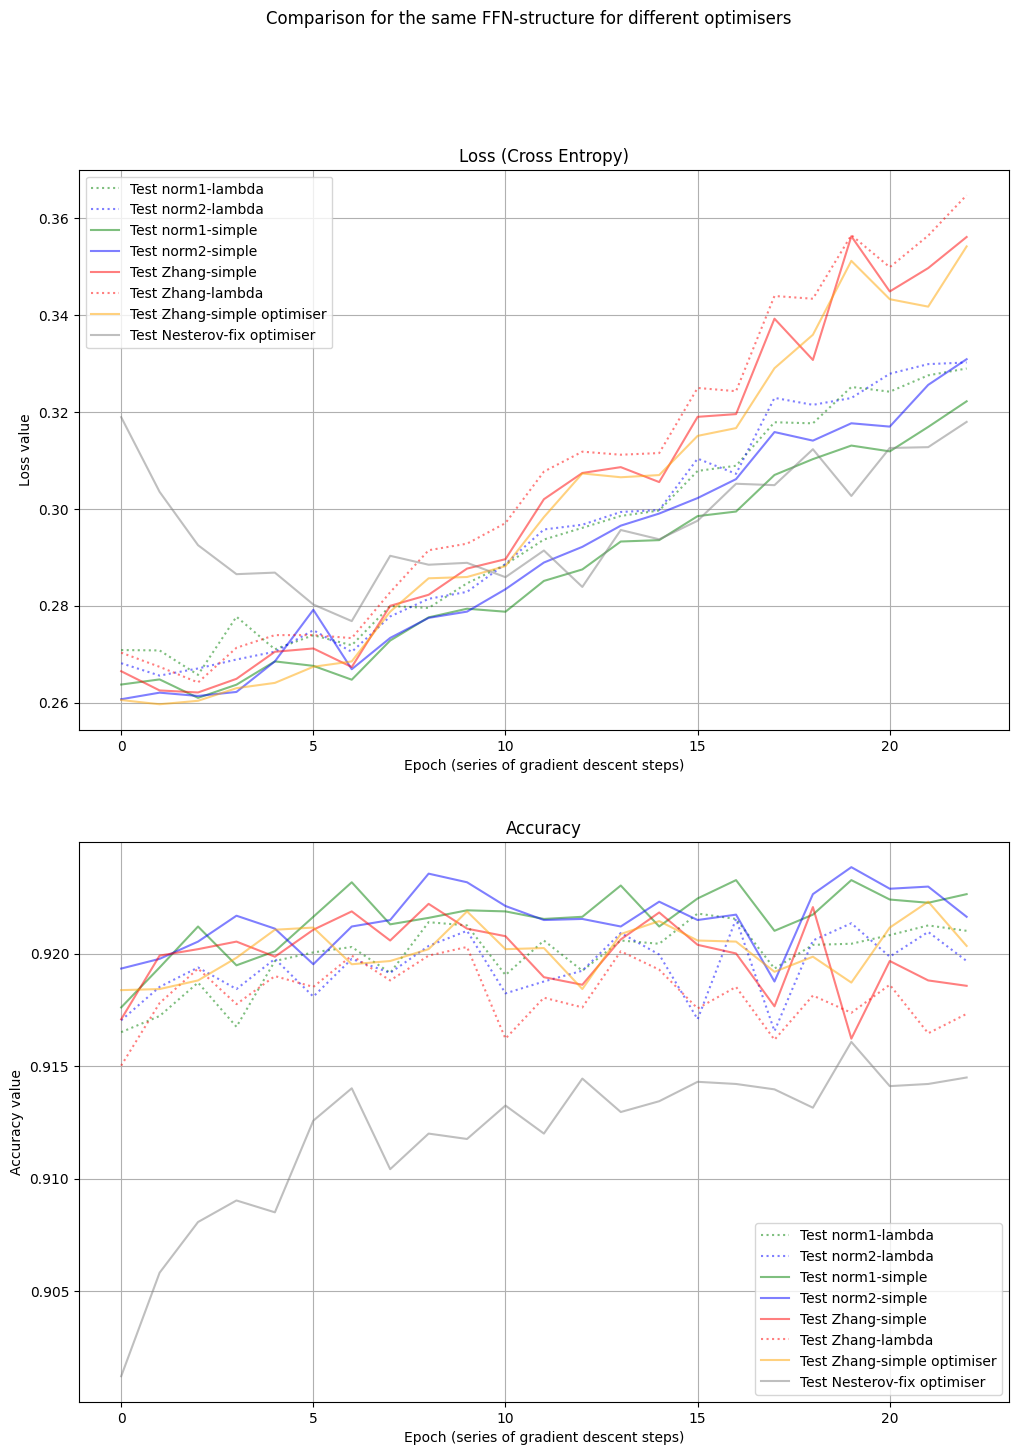

In [14]:
print_comparison(5, 100)

In [16]:
print(HISTORY_NORM1S['test_accuracy'][-1], HISTORY_NORM2S['test_accuracy'][-1])

0.9226418711656442 0.9216353527607362
